# LangGraph Flow Notes

This notebook documents the LangGraph workflow defined in `build_app()` and renders the compiled graph from the project code.

Use it to review the research-agent control flow without running a full research session.

## Flow Summary

The graph has three main control paths:

1. Guardrail path: `START -> initialize_run_node -> evaluate_guardrails_node -> guardrail_block_node -> END` when the request is blocked.
2. History path: `load_history_node -> history_review_node -> history_review_gate_node`, then either reuse a previous report or continue into planning.
3. Research loop: `planner_node -> prepare_search_node -> tool_access_gate_node -> search_node`, then tool execution and reasoning repeat until the graph can synthesise, review, publish, and save history.

g:\AI Training\captone_project\capstone-projects\research_assist\tools.py:29: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearch(


## Rendered LangGraph Diagram

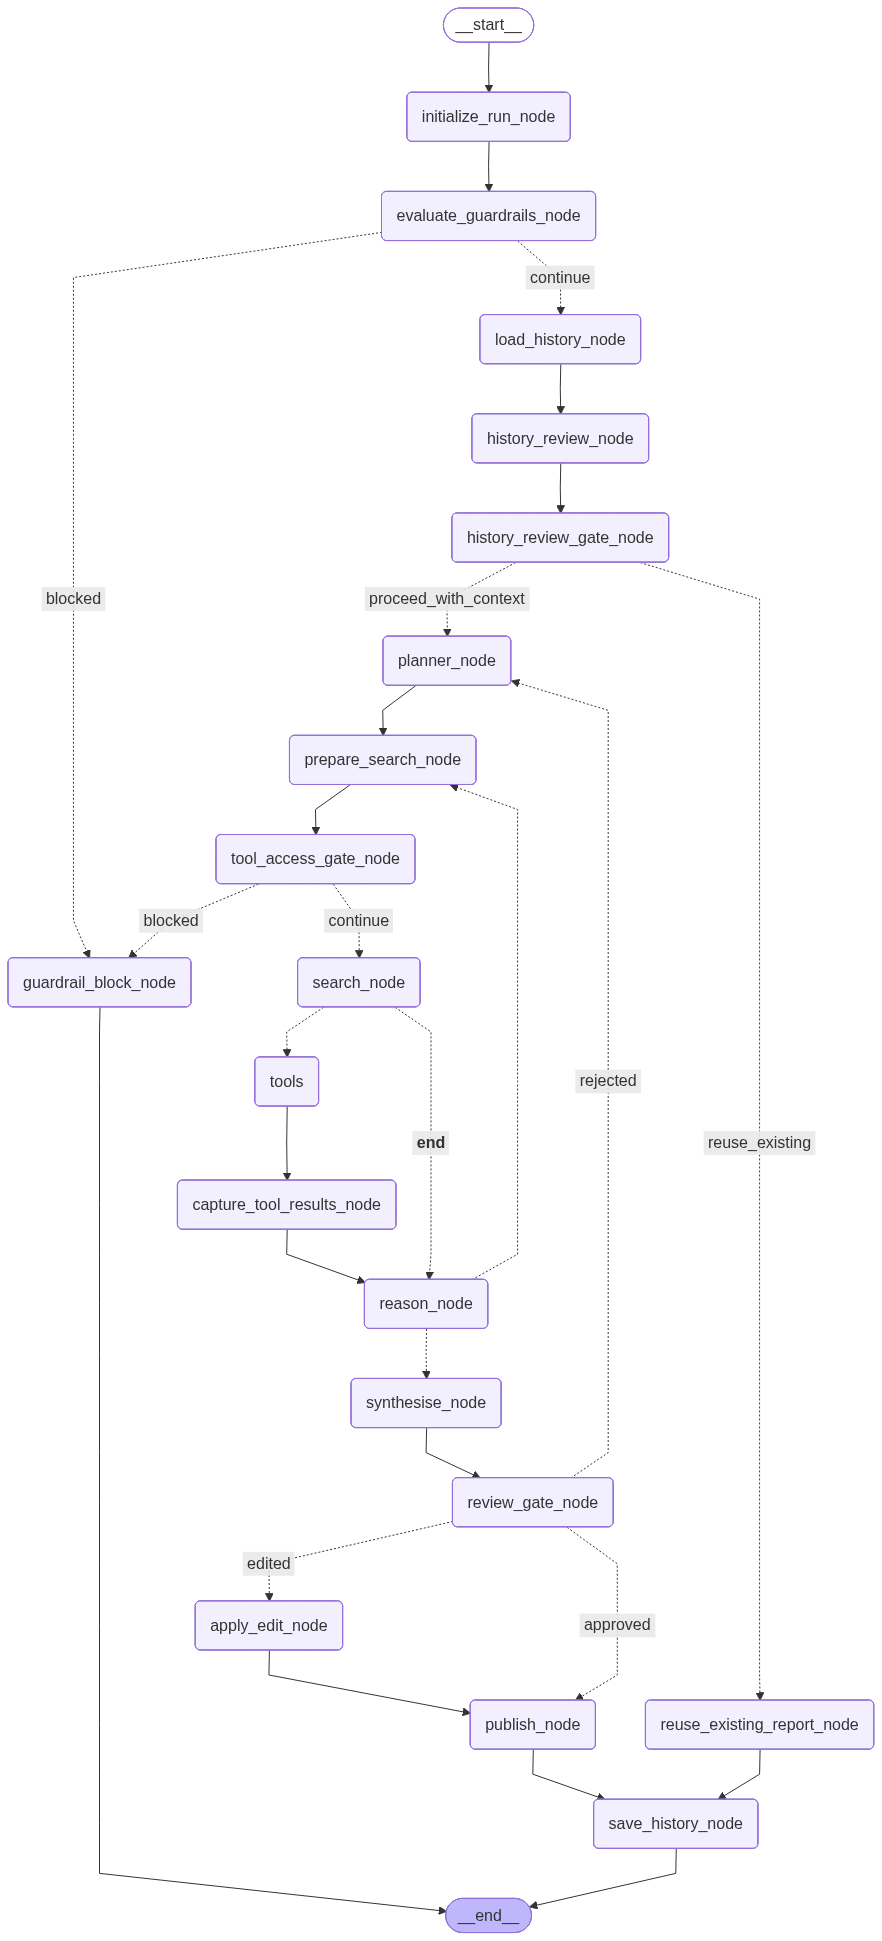

In [1]:
from IPython.display import Image, Markdown, display
import importlib
import graph

importlib.reload(graph)
from graph import build_app

app = build_app()
display(Markdown("## Rendered LangGraph Diagram"))
display(Image(app.get_graph().draw_mermaid_png()))

## Node Transitions

The important conditional branches in `graph.py` are:

- `evaluate_guardrails_node`: routes to `load_history_node` or `guardrail_block_node`.
- `history_review_gate_node`: routes to `planner_node` or `reuse_existing_report_node`.
- `tool_access_gate_node`: routes to `search_node` or `guardrail_block_node` if no approved tools are available.
- `search_node`: routes to `tools` when a tool call is emitted, otherwise to `reason_node`.
- `reason_node`: loops back to `prepare_search_node` or continues to `synthesise_node`.
- `review_gate_node`: routes to `publish_node`, `apply_edit_node`, or back to `planner_node`.

In [2]:
mermaid_text = app.get_graph().draw_mermaid()
display(Markdown("## Mermaid Source"))
print(mermaid_text)

## Mermaid Source

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	initialize_run_node(initialize_run_node)
	evaluate_guardrails_node(evaluate_guardrails_node)
	guardrail_block_node(guardrail_block_node)
	load_history_node(load_history_node)
	history_review_node(history_review_node)
	history_review_gate_node(history_review_gate_node)
	reuse_existing_report_node(reuse_existing_report_node)
	planner_node(planner_node)
	prepare_search_node(prepare_search_node)
	tool_access_gate_node(tool_access_gate_node)
	search_node(search_node)
	tools(tools)
	capture_tool_results_node(capture_tool_results_node)
	reason_node(reason_node)
	synthesise_node(synthesise_node)
	review_gate_node(review_gate_node)
	apply_edit_node(apply_edit_node)
	publish_node(publish_node)
	save_history_node(save_history_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> initialize_run_node;
	apply_edit_node --> publish_node;
	capture_tool_results_node --> reason_node;
	evaluate_guardrails_no